# Case Study: Convex Hull of Embeddings

In [1]:
import pandas as pd
import numpy as np
import torch
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from tqdm import tqdm
from analysis_functions import load_model, get_attention, attention_to_distance, evaluate_model

In [11]:
def extract_embedding(text, real_answer, model_id):
    model, tokenizer = load_model(model_id)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        generation = model.generate(
            **inputs,
            max_new_tokens=200,
            pad_token_id=tokenizer.eos_token_id,
            return_dict_in_generate=True,
        )

    full_tokens = generation.sequences[0]

    input_length = inputs["input_ids"].shape[1]
    llm_tokens = full_tokens[input_length:]

    llm_answer = tokenizer.decode(
        llm_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    # run the complete generated sequence through the model
    with torch.no_grad():
        outputs = model(
            input_ids=full_tokens.unsqueeze(0),
            output_hidden_states=True
        )

    # last layer: [1, sequence_length, hidden_dimension]
    hidden_states = outputs.hidden_states[-1][0]

    # keep only the generated-answer token embeddings
    llm_embeddings = hidden_states

    correctness = evaluate_model(real_answer, llm_answer)

    print("llm answer: ", llm_answer)
    print("true answer: ", real_answer)
    print("token IDs shape:", llm_tokens.shape)
    print("embedding shape:", llm_embeddings.shape)

    return llm_embeddings, llm_tokens, llm_answer, correctness

In [6]:
## == DATASETS == ##
# [0]: hellaswag, [1]-[5]: mmlu
datasets = [["hellaswag", "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"],
            ["mmlu_law", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv"],
            ["mmlu_math", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv"],
            ["mmlu_misc", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv"],
            ["mmlu_moral", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv"],
            ["mmlu_psych", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv"],
            ["mcqa", "~/TDA_RI/TDA_reason-interpret/datasets/mcqa.csv"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "llama"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "qwen"],
          ["Mistral 7B v0.3", "mistralai/Mistral-7B-v0.3", "mistral"]]

## == FINETUNED MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models_ft = [["Llama 3.1 8B ft. Hellaswag", "kimlopez/llama_hellaswag", "llama_ft"],
          ["Qwen 3 8B ft. Hellaswag", "kimlopez/qwen_hellaswag", "qwen_ft"],
          ["Mistral 7B v0.3 ft. Hellaswag", "kimlopez/mistral_hellaswag", "mistral_ft"]]

In [23]:
def graph_corr_incorr(texts, model_id):
    for text in texts:
        llm_embeddings, llm_tokens, llm_answer, correctness = extract_embedding(text["prompt"], text["label"], model_id)
        tokens_2d = PCA(n_components=2).fit_transform(llm_embeddings.detach().cpu().numpy())
    
        hull = ConvexHull(tokens_2d)
        points = tokens_2d[hull.vertices]

        if correctness:
            pt_color="blue"
            line_color="blue"
        else:
            pt_color="red"
            line_color="red"
    
        plt.scatter(
            tokens_2d[:, 0],
            tokens_2d[:, 1],
            s=20,
            alpha=0.7,
            color=pt_color
        )
        
        plt.scatter(tokens_2d[:, 0], tokens_2d[:, 1], s=20, color=pt_color)
        
        plt.plot(
            points[:, 0],
            points[:, 1],
            color=line_color
        )
        
    plt.title("Correct vs. Incorrect Embeddings")
    plt.show()

    return 0

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

llm answer:   D
true answer:  2
token IDs shape: torch.Size([2])
embedding shape: torch.Size([74, 4096])


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

llm answer:   C
true answer:  2
token IDs shape: torch.Size([2])
embedding shape: torch.Size([66, 4096])


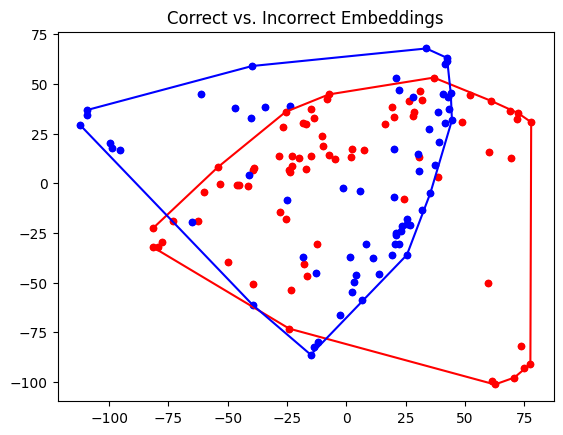

0

In [26]:
text_1 = pd.read_csv(datasets[0][1])
text_2 = pd.read_csv(datasets[0][1])

texts = [text_1.iloc[0], text_2.iloc[1]]
model_id = models[0][1]

graph_corr_incorr(texts, model_id)